# WaveSplit

### Učitavanje biblioteka

In [71]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

### Putanja do audio fajla

In [72]:
audio_path = './songs/bob_marley_three_little_birds.wav'

### Učitavanje audio fajla - pesme

In [73]:
signal, sr = librosa.load(
    path=audio_path,
    sr=44100,
    mono=True
)

*Sample rate* standardizujemo na 44100Hz - to znači da postoji 44100 uzoraka u sekundi.

Takodje stereo signal pretvaramo u *mono* kako bi nam analiza i Short-time Fourier Transormation (STFT) bila lakša.

### Normalizacija signala

Normalizaciju signala radimo sa ciljem kako bismo amplitude signala ograničili intervalom od -1 do 1.

In [74]:
signal = signal / np.max(np.abs(signal))

### Prikaz osnovnih informacija o audio fajlu

In [75]:
print(f'Sample Rate: {sr}[Hz]')
print(f'Broj uzoraka: {len(signal)}')
print(f'Trajanje pesme: {round(len(signal) / sr, 2)} sekundi')

Sample Rate: 44100[Hz]
Broj uzoraka: 7979008
Trajanje pesme: 180.93 sekundi


### Detekcija Onset-a

In [76]:
onset_env = librosa.onset.onset_strength(
    y=signal,
    sr=sr
)

Nakon što librosa interno uradi STFT, meri se koliko se spektar promenio između frame-ova. Iz toga se dobija niz vrednosti, te ukoliko je vrednost velika, to predstavlja veliku promenu energije, dok mala vrednost predstavlja stabilan signal.

*Onset strength envelope* prikazuje gde se dešavaju ritmički udarci.

### Prikaz onset envelop-a

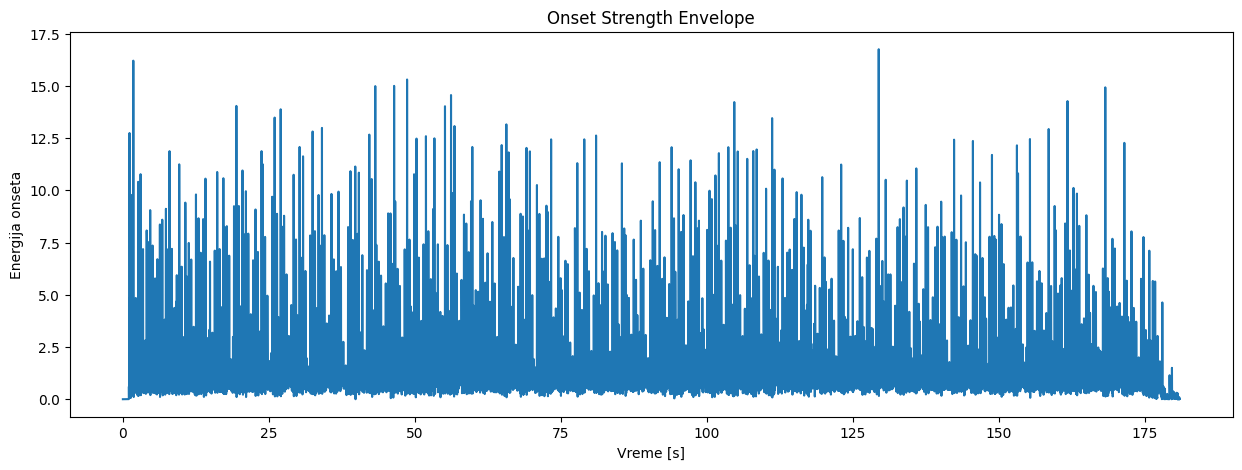

In [77]:
times = librosa.times_like(
    onset_env,
    sr=sr
)
plt.figure(figsize=(15, 5))
plt.plot(times, onset_env)
plt.title('Onset Strength Envelope')
plt.xlabel('Vreme [s]')
plt.ylabel('Energija onseta')
plt.show()

### Detekcija BPM-a

Librosa ovde analizira periodičnost onset-a, pronalazi dominantni tempo i određuje poziciju beat-ova.

**Potencijalni problem:** Half-time ili Double-time

Ovaj problem nastaje jer se periodicnost može detektovati na više nivoa. Na primer, može se desiti da je tempo pesme 70bpm, a da algoritam vrati 140bpm ili obrnuto. Ovaj problem ćemo kasnije rešiti detekcijom tempa iz izolovanih perkusija.

In [78]:
tempo, beat_frames = librosa.beat.beat_track(
    onset_envelope=onset_env,
    sr=sr
)
tempo = tempo[0]
print(f'Detektovani BPM: {round(float(tempo), 0)}bpm')

Detektovani BPM: 148.0bpm


### Konverzija Frame-ova u vreme

In [79]:
beat_times = librosa.frames_to_time(
    beat_frames,
    sr=sr
)

### Prikaz waveform-a sa BPM-om

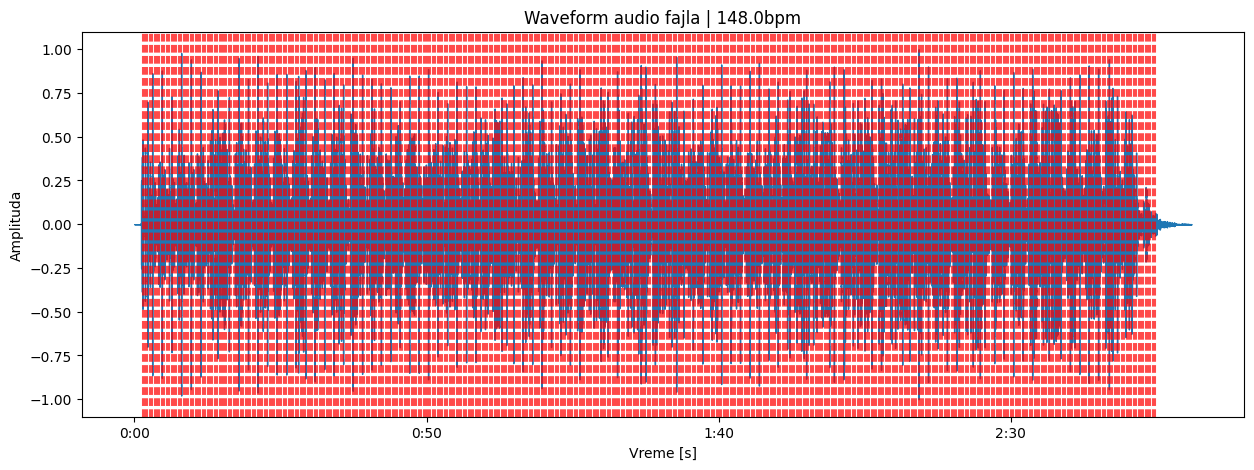

In [80]:
plt.figure(figsize=(15, 5))
librosa.display.waveshow(
    signal,
    sr=sr
)

for beat in beat_times:
    plt.axvline(
        x=beat,
        color='red',
        linestyle='--',
        alpha=0.7
    )

plt.title(f'Waveform audio fajla | {round(float(tempo), 0)}bpm')
plt.xlabel('Vreme [s]')
plt.ylabel('Amplituda')
plt.show()

### Short-Time Fourier Transformation

In [81]:
n_fft = 2048    # velicina FFT prozora
hop_length = 512    # velicina pomeraja izmedju frame-ova

In [82]:
stft = librosa.stft(
    signal,
    n_fft=n_fft,
    hop_length=hop_length
)

### Spektogram

In [83]:
spectogram = np.abs(stft)

In [84]:
# Konverzija u decibele [dB]
spectogram_db = librosa.amplitude_to_db(
    spectogram,
    ref=np.max
)

### Prikaz spektograma

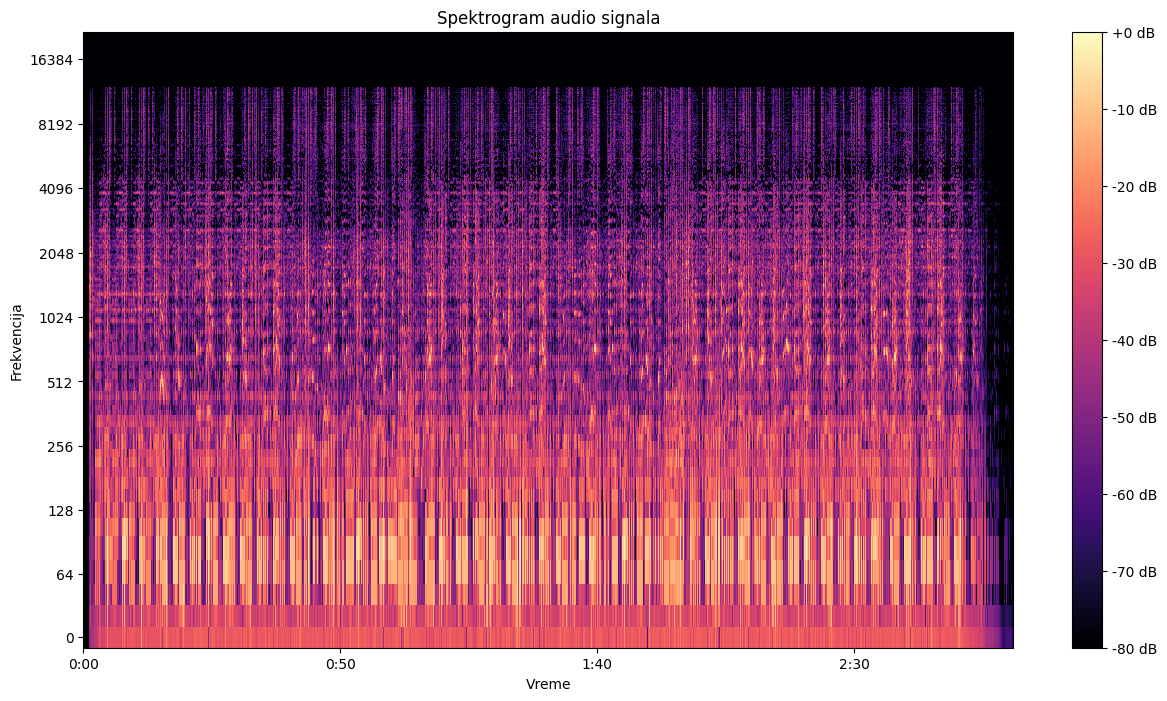

In [85]:
plt.figure(figsize=(15, 8))
librosa.display.specshow(
    spectogram_db,
    sr=sr,
    hop_length=hop_length,
    y_axis='log',
    x_axis='time'
)
plt.colorbar(format='%+2.0f dB')
plt.title("Spektrogram audio signala")
plt.xlabel("Vreme")
plt.ylabel("Frekvencija")
plt.show()